In [5]:
import pandas as pd

# Lets import datasets

In [8]:
movies = pd.read_csv(r"/content/drive/MyDrive/movie.csv")
movies.shape

(27278, 3)

In [22]:
ratings = pd.read_csv(r"/content/rating.csv")
ratings.shape

(20000263, 4)

In [18]:
tags = pd.read_csv(r"/content/drive/MyDrive/tag.csv")
tags.shape

(465564, 4)

In [20]:
tags.columns

Index(['userId', 'movieId', 'tag', 'timestamp'], dtype='object')

In [23]:
ratings.columns

Index(['userId', 'movieId', 'rating', 'timestamp'], dtype='object')

# For current analysis we will remove timestamp

In [24]:
del ratings['timestamp']
del tags['timestamp']

In [26]:
print(rating.columns)
print(tags.columns)

Index(['movieId', 'title', 'genres'], dtype='object')
Index(['userId', 'movieId', 'tag'], dtype='object')


# DAta Structure

* Series

In [28]:
tags.head()

,userId,movieId,tag
0,18,4141,Mark Waters
1,65,208,dark hero
2,65,353,dark hero
3,65,521,noir thriller
4,65,592,dark hero


In [33]:
print(type(movies))
movies.head(20)

<class 'pandas.core.frame.DataFrame'>


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy
5,6,Heat (1995),Action|Crime|Thriller
6,7,Sabrina (1995),Comedy|Romance
7,8,Tom and Huck (1995),Adventure|Children
8,9,Sudden Death (1995),Action
9,10,GoldenEye (1995),Action|Adventure|Thriller


In [31]:
tags.iloc()

In [30]:
raw_0 = tags.iloc[1]
print(raw_0)

userId            65
movieId          208
tag        dark hero
Name: 1, dtype: object


In [32]:
raw_0.index

Index(['userId', 'movieId', 'tag'], dtype='object')

In [35]:
raw_0['userId']

np.int64(65)

In [37]:
'rating' in raw_0


False

In [38]:
raw_0.name

1

In [39]:
row_0 = raw_0.rename('firstRow')
row_0.name

'firstRow'

# DATA Frames

In [40]:
tags.head()

,userId,movieId,tag
0,18,4141,Mark Waters
1,65,208,dark hero
2,65,353,dark hero
3,65,521,noir thriller
4,65,592,dark hero


In [41]:
tags.index

RangeIndex(start=0, stop=465564, step=1)

In [42]:
tags.columns

Index(['userId', 'movieId', 'tag'], dtype='object')

In [43]:
tags.iloc[[0,11,500]]

,userId,movieId,tag
0,18,4141,Mark Waters
11,65,1783,noir thriller
500,342,55908,entirely dialogue


# Descriptive Statistics

Lets look how the rating are distributed!

In [44]:
ratings['rating'].describe()

,rating
count,2.000026e+07
mean,3.525529e+00
std,1.051989e+00
min,5.000000e-01
25%,3.000000e+00
50%,3.500000e+00
75%,4.000000e+00
max,5.000000e+00


In [45]:
ratings.describe()

,userId,movieId,rating
count,2.000026e+07,2.000026e+07,2.000026e+07
mean,6.904587e+04,9.041567e+03,3.525529e+00
std,4.003863e+04,1.978948e+04,1.051989e+00
min,1.000000e+00,1.000000e+00,5.000000e-01
25%,3.439500e+04,9.020000e+02,3.000000e+00
50%,6.914100e+04,2.167000e+03,3.500000e+00
75%,1.036370e+05,4.770000e+03,4.000000e+00
max,1.384930e+05,1.312620e+05,5.000000e+00


In [47]:
ratings.columns

Index(['userId', 'movieId', 'rating'], dtype='object')

In [46]:
ratings['rating'].mean()

np.float64(3.5255285642993797)

In [48]:
ratings.mean()

,0
userId,69045.872583
movieId,9041.567330
rating,3.525529


In [50]:
ratings['rating'].min()

0.5

In [51]:
ratings['rating'].max()

5.0

In [52]:
ratings['rating'].std()

1.051988919275684

In [54]:
ratings['rating'].mode()

,rating
0,4.0


In [55]:
ratings.corr()

,userId,movieId,rating
userId,1.000000,-0.000850,0.001175
movieId,-0.000850,1.000000,0.002606
rating,0.001175,0.002606,1.000000


In [56]:
filter1 = ratings["rating"] >10
print(filter1)
print(type(filter1))
filter1.any()

0           False
1           False
2           False
3           False
4           False
            ...  
20000258    False
20000259    False
20000260    False
20000261    False
20000262    False
Name: rating, Length: 20000263, dtype: bool
<class 'pandas.core.series.Series'>


np.False_

In [58]:
filter2 =ratings['rating'] >0
print(filter2)
print(type(filter2))
filter2.all()

0           True
1           True
2           True
3           True
4           True
            ... 
20000258    True
20000259    True
20000260    True
20000261    True
20000262    True
Name: rating, Length: 20000263, dtype: bool
<class 'pandas.core.series.Series'>


np.True_

# Data Cleaning : Handaling Missing Data

In [59]:
movies.shape

(27278, 3)

In [60]:
movies.isnull().any().any()

np.False_



*   NO Null Values in movies set




In [62]:
ratings.shape

(20000263, 3)

In [63]:
ratings.isnull().any().any()

np.False_

In [64]:
tags.shape

(465564, 3)

In [65]:
tags.isnull().any().any()

np.True_



*   Above tag value which are NULL Value



In [66]:
tags = tags.dropna() # Remove data from missing or Null value

In [67]:
tags.isnull().any().any()

np.False_

In [68]:
tags.shape

(465548, 3)



*  No NULL values ! Notice the number of lines have reduced.


## DATA VISUALIZATION

array([[<Axes: title={'center': 'rating'}>]], dtype=object)

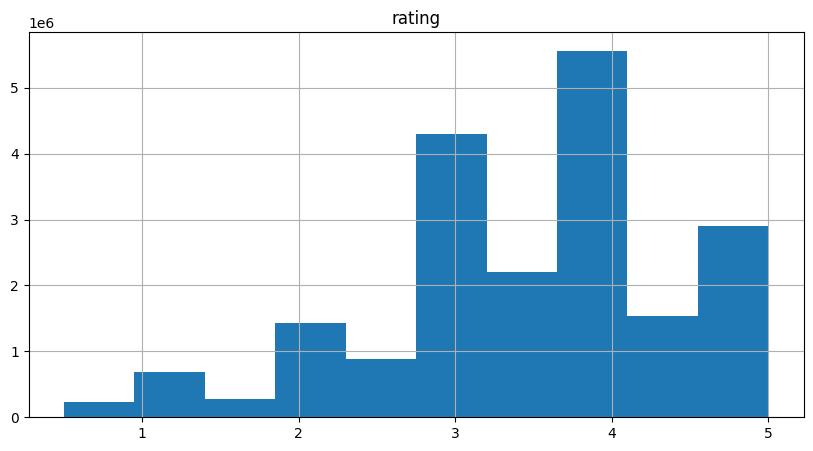

In [69]:
%matplotlib inline

ratings.hist(column='rating', figsize=(10,5))

<Axes: >

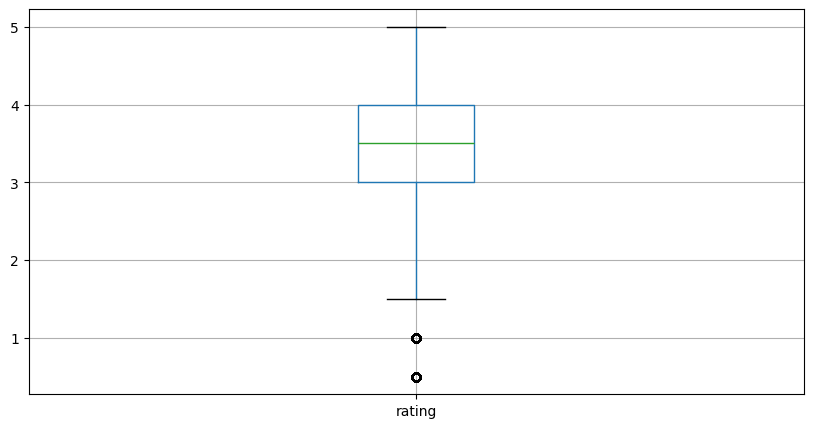

In [70]:
ratings.boxplot(column='rating', figsize=(10,5))

## Slicing Out Columns

In [71]:
tags['tag'].head()

,tag
0,Mark Waters
1,dark hero
2,dark hero
3,noir thriller
4,dark hero


In [72]:
movies[['title','genres']].head()

,title,genres
0,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,Jumanji (1995),Adventure|Children|Fantasy
2,Grumpier Old Men (1995),Comedy|Romance
3,Waiting to Exhale (1995),Comedy|Drama|Romance
4,Father of the Bride Part II (1995),Comedy


In [73]:
ratings[-10:]

,userId,movieId,rating
20000253,138493,60816,4.5
20000254,138493,61160,4.0
20000255,138493,65682,4.5
20000256,138493,66762,4.5
20000257,138493,68319,4.5
20000258,138493,68954,4.5
20000259,138493,69526,4.5
20000260,138493,69644,3.0
20000261,138493,70286,5.0
20000262,138493,71619,2.5


In [75]:
tag_counts = tags['tag'].value_counts()
tag_counts[-10:]

,count
tag,
Hell naw,1
This is my happy face,1
I heel toe on Uday's house,1
Why?,1
Bobo,1
Diamond Dallas Page,1
I'm Devon Butler!,1
No arguement,1
Really Bad,1


<Axes: xlabel='tag'>

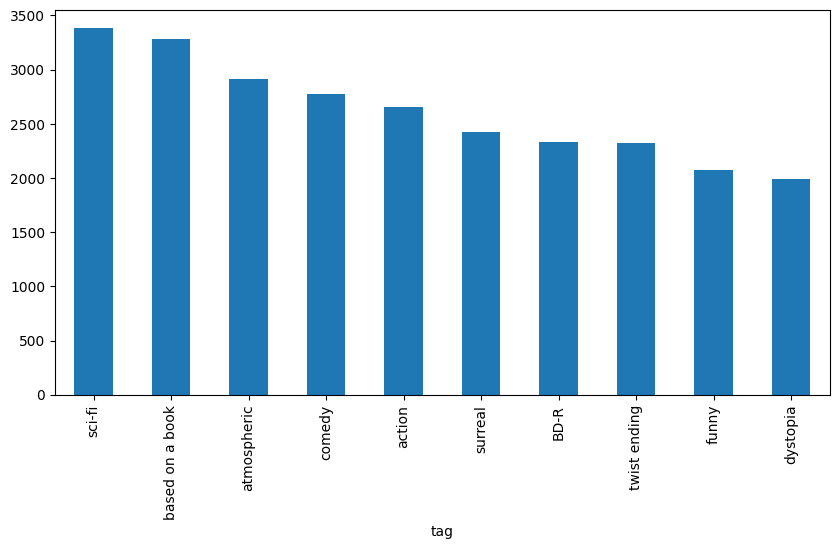

In [76]:
tag_counts[:10].plot(kind='bar', figsize=(10,5))

## Filters for Selecting Rows¶

In [77]:
is_highly_rated = ratings['rating'] >= 5.0
ratings[is_highly_rated][30:50]

,userId,movieId,rating
239,3,50,5.0
242,3,175,5.0
244,3,223,5.0
245,3,260,5.0
246,3,316,5.0
247,3,318,5.0
248,3,329,5.0
252,3,457,5.0
253,3,480,5.0
254,3,490,5.0


In [78]:
is_action= movies['genres'].str.contains('Action')
movies[is_action][5:15]

,movieId,title,genres
22,23,Assassins (1995),Action|Crime|Thriller
41,42,Dead Presidents (1995),Action|Crime|Drama
43,44,Mortal Kombat (1995),Action|Adventure|Fantasy
50,51,Guardian Angel (1994),Action|Drama|Thriller
65,66,Lawnmower Man 2: Beyond Cyberspace (1996),Action|Sci-Fi|Thriller
69,70,From Dusk Till Dawn (1996),Action|Comedy|Horror|Thriller
70,71,Fair Game (1995),Action
75,76,Screamers (1995),Action|Sci-Fi|Thriller
77,78,"Crossing Guard, The (1995)",Action|Crime|Drama|Thriller
85,86,White Squall (1996),Action|Adventure|Drama


In [79]:
movies[is_action].head(15)

,movieId,title,genres
5,6,Heat (1995),Action|Crime|Thriller
8,9,Sudden Death (1995),Action
9,10,GoldenEye (1995),Action|Adventure|Thriller
14,15,Cutthroat Island (1995),Action|Adventure|Romance
19,20,Money Train (1995),Action|Comedy|Crime|Drama|Thriller
22,23,Assassins (1995),Action|Crime|Thriller
41,42,Dead Presidents (1995),Action|Crime|Drama
43,44,Mortal Kombat (1995),Action|Adventure|Fantasy
50,51,Guardian Angel (1994),Action|Drama|Thriller
65,66,Lawnmower Man 2: Beyond Cyberspace (1996),Action|Sci-Fi|Thriller


##  👥 Group By and Aggregate¶

In [80]:
ratings_count = ratings[['movieId','rating']].groupby('rating').count()
ratings_count

,movieId
rating,
0.5,239125
1.0,680732
1.5,279252
2.0,1430997
2.5,883398
3.0,4291193
3.5,2200156
4.0,5561926
4.5,1534824


In [81]:
average_rating = ratings[['movieId','rating']].groupby('movieId').mean()
average_rating.head()

,rating
movieId,
1,3.921240
2,3.211977
3,3.151040
4,2.861393
5,3.064592


In [82]:
movie_count = ratings[['movieId','rating']].groupby('movieId').count()
movie_count.head()

,rating
movieId,
1,49695
2,22243
3,12735
4,2756
5,12161


In [83]:
movie_count = ratings[['movieId','rating']].groupby('movieId').count()
movie_count.tail()

,rating
movieId,
131254,1
131256,1
131258,1
131260,1
131262,1


## 🔰 Merge Dataframes¶

In [84]:
tags.head()

,userId,movieId,tag
0,18,4141,Mark Waters
1,65,208,dark hero
2,65,353,dark hero
3,65,521,noir thriller
4,65,592,dark hero


In [85]:
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [86]:
t = movies.merge(tags, on='movieId', how='inner')
t.head()

,movieId,title,genres,userId,tag
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,1644,Watched
1,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,1741,computer animation
2,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,1741,Disney animated feature
3,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,1741,Pixar animation
4,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,1741,TÃ©a Leoni does not star in this movie


## 📚 Combine aggreagation, merging, and filters to get useful analytics¶

In [87]:
avg_ratings= ratings.groupby('movieId', as_index=False).mean()
del avg_ratings['userId']
avg_ratings.head()

,movieId,rating
0,1,3.921240
1,2,3.211977
2,3,3.151040
3,4,2.861393
4,5,3.064592


In [88]:
box_office = movies.merge(avg_ratings, on='movieId', how='inner')
box_office.tail()

,movieId,title,genres,rating
26739,131254,Kein Bund für's Leben (2007),Comedy,4.0
26740,131256,"Feuer, Eis & Dosenbier (2002)",Comedy,4.0
26741,131258,The Pirates (2014),Adventure,2.5
26742,131260,Rentun Ruusu (2001),(no genres listed),3.0
26743,131262,Innocence (2014),Adventure|Fantasy|Horror,4.0


In [89]:
s_highly_rated = box_office['rating'] >= 4.0
box_office[is_highly_rated][-5:]

/tmp/ipykernel_447/4215303396.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  box_office[is_highly_rated][-5:]


,movieId,title,genres,rating
26522,130036,Saints and Soldiers: The Void (2014),Action|Drama|War,3.5
26551,130326,Other Girls (2015),Drama,4.0
26580,130454,Michael Laudrup - en Fodboldspiller,(no genres listed),4.0
26656,131009,Ballermann 6 (1997),Comedy,3.5
26676,131070,Forgotten (2012),Drama|Mystery|Thriller,2.5


In [90]:
is_Adventure = box_office['genres'].str.contains('Adventure')
box_office[is_Adventure][:5]

,movieId,title,genres,rating
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,3.921240
1,2,Jumanji (1995),Adventure|Children|Fantasy,3.211977
7,8,Tom and Huck (1995),Adventure|Children,3.142049
9,10,GoldenEye (1995),Action|Adventure|Thriller,3.430029
12,13,Balto (1995),Adventure|Animation|Children,3.272416


In [91]:
box_office[is_Adventure & is_highly_rated][-5:]

/tmp/ipykernel_447/3627520723.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  box_office[is_Adventure & is_highly_rated][-5:]


,movieId,title,genres,rating
25387,122421,The Six Million Dollar Man (1973),Adventure|Sci-Fi,2.500
25414,122764,Napoleon (1995),Adventure|Children,3.000
25494,123596,One Spy Too Many (1966),Adventure|Crime,2.500
25623,125271,The Roots of Heaven (1958),Adventure|Drama,3.000
25893,126733,Help! I'm A Fish (2001),Adventure|Animation|Comedy,2.625


## 📝 Vectorized String Operations¶


In [92]:
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


## 🔬 Split 'genres' into multiple columns¶

In [93]:
movie_genres = movies['genres'].str.split('|', expand=True)

In [94]:
movie_genres[:10]

,0,1,2,3,4,5,6,7,8,9
0,Adventure,Animation,Children,Comedy,Fantasy,None,None,None,None,None
1,Adventure,Children,Fantasy,None,None,None,None,None,None,None
2,Comedy,Romance,None,None,None,None,None,None,None,None
3,Comedy,Drama,Romance,None,None,None,None,None,None,None
4,Comedy,None,None,None,None,None,None,None,None,None
5,Action,Crime,Thriller,None,None,None,None,None,None,None
6,Comedy,Romance,None,None,None,None,None,None,None,None
7,Adventure,Children,None,None,None,None,None,None,None,None
8,Action,None,None,None,None,None,None,None,None,None
9,Action,Adventure,Thriller,None,None,None,None,None,None,None


## 🚩 Add a new column for comedy genre flag¶


In [95]:
movie_genres['isComedy'] = movies['genres'].str.contains('Comedy')


In [96]:
movie_genres[:10]

,0,1,2,3,4,5,6,7,8,9,isComedy
0,Adventure,Animation,Children,Comedy,Fantasy,None,None,None,None,None,True
1,Adventure,Children,Fantasy,None,None,None,None,None,None,None,False
2,Comedy,Romance,None,None,None,None,None,None,None,None,True
3,Comedy,Drama,Romance,None,None,None,None,None,None,None,True
4,Comedy,None,None,None,None,None,None,None,None,None,True
5,Action,Crime,Thriller,None,None,None,None,None,None,None,False
6,Comedy,Romance,None,None,None,None,None,None,None,None,True
7,Adventure,Children,None,None,None,None,None,None,None,None,False
8,Action,None,None,None,None,None,None,None,None,None,False
9,Action,Adventure,Thriller,None,None,None,None,None,None,None,False


## 📟 Extract year from title e.g. (2007)¶

In [97]:
movies['year'] = movies['title'].str.extract('.*\((.*)\).*', expand=True)

<>:1: SyntaxWarning: invalid escape sequence '\('
<>:1: SyntaxWarning: invalid escape sequence '\('
/tmp/ipykernel_447/702884181.py:1: SyntaxWarning: invalid escape sequence '\('
  movies['year'] = movies['title'].str.extract('.*\((.*)\).*', expand=True)


In [98]:
movies.tail()


,movieId,title,genres,year
27273,131254,Kein Bund für's Leben (2007),Comedy,2007
27274,131256,"Feuer, Eis & Dosenbier (2002)",Comedy,2002
27275,131258,The Pirates (2014),Adventure,2014
27276,131260,Rentun Ruusu (2001),(no genres listed),2001
27277,131262,Innocence (2014),Adventure|Fantasy|Horror,2014


## 🕐 Parsing Timestamps¶



*   Timestamps are common in sensor data or other time series datasets. Let us revisit the tags.csv dataset and read the timestamps!




In [99]:
tags = pd.read_csv(r"/content/drive/MyDrive/tag.csv")
tags.dtypes

,0
userId,int64
movieId,int64
tag,object
timestamp,object


In [100]:
tags = pd.read_csv(r"/content/drive/MyDrive/tag.csv", sep=',')
tags.dtypes

,0
userId,int64
movieId,int64
tag,object
timestamp,object




*   Unix time / POSIX time / epoch time records time in seconds


since midnight Coordinated Universal Time (UTC) of April 4, 2009




In [101]:
tags.head(5)


,userId,movieId,tag,timestamp
0,18,4141,Mark Waters,2009-04-24 18:19:40
1,65,208,dark hero,2013-05-10 01:41:18
2,65,353,dark hero,2013-05-10 01:41:19
3,65,521,noir thriller,2013-05-10 01:39:43
4,65,592,dark hero,2013-05-10 01:41:18


In [103]:
tags['parsed_time'] = pd.to_datetime(tags['timestamp'])




*   Data Type datetime64[ns] maps to either




In [104]:
tags['parsed_time'].dtype

dtype('<M8[ns]')

In [105]:
tags.head(2)

,userId,movieId,tag,timestamp,parsed_time
0,18,4141,Mark Waters,2009-04-24 18:19:40,2009-04-24 18:19:40
1,65,208,dark hero,2013-05-10 01:41:18,2013-05-10 01:41:18


# Selecting rows based on timestamps

In [106]:
greater_than_t = tags['parsed_time'] > '2015-02-01'

selected_rows = tags[greater_than_t]

tags.shape, selected_rows.shape

((465564, 5), (12130, 5))

## Sorting the table using the timestamps

In [107]:
tags.sort_values(by='parsed_time', ascending=True)[:10]

,userId,movieId,tag,timestamp,parsed_time
333932,100371,2788,monty python,2005-12-24 13:00:10,2005-12-24 13:00:10
333927,100371,1732,coen brothers,2005-12-24 13:00:36,2005-12-24 13:00:36
333924,100371,1206,stanley kubrick,2005-12-24 13:00:48,2005-12-24 13:00:48
333923,100371,1193,jack nicholson,2005-12-24 13:02:51,2005-12-24 13:02:51
333939,100371,5004,peter sellers,2005-12-24 13:03:19,2005-12-24 13:03:19
333922,100371,47,morgan freeman,2005-12-24 13:03:32,2005-12-24 13:03:32
333921,100371,47,brad pitt,2005-12-24 13:03:32,2005-12-24 13:03:32
333936,100371,4011,brad pitt,2005-12-24 13:03:51,2005-12-24 13:03:51
333937,100371,4011,guy ritchie,2005-12-24 13:03:51,2005-12-24 13:03:51
333920,100371,32,bruce willis,2005-12-24 13:04:02,2005-12-24 13:04:02


## 📇 Average Movie Ratings over Time¶

Movie ratings related to the year of launch?


In [108]:
average_rating = ratings[['movieId','rating']].groupby('movieId', as_index=False).mean()
average_rating.tail()

,movieId,rating
26739,131254,4.0
26740,131256,4.0
26741,131258,2.5
26742,131260,3.0
26743,131262,4.0


In [110]:
joined = movies.merge(average_rating, on='movieId', how='inner')
joined.head()
#joined.corr()

,movieId,title,genres,year,rating
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,1995,3.921240
1,2,Jumanji (1995),Adventure|Children|Fantasy,1995,3.211977
2,3,Grumpier Old Men (1995),Comedy|Romance,1995,3.151040
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance,1995,2.861393
4,5,Father of the Bride Part II (1995),Comedy,1995,3.064592


In [111]:
joined = movies.merge(average_rating, on='movieId', how='inner')
#joined.head()
joined.corr()

ValueError: could not convert string to float: 'Toy Story (1995)'

In [112]:
print(joined.dtypes)


movieId      int64
title       object
genres      object
year        object
rating     float64
dtype: object


In [113]:
numeric_cols = joined.select_dtypes(include=['number'])
display(numeric_cols.corr())


,movieId,rating
movieId,1.000000,-0.090369
rating,-0.090369,1.000000
